<a href="https://colab.research.google.com/github/RichardMorris/TRUR2290-25-26/blob/main/exponential_regression_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exponential Regression Example

### Download Data set

In [ ]:
!curl -L -o ./exponen-regression.zip https://www.kaggle.com/api/v1/datasets/download/patricklford/amazon-alibaba-and-ebay-2013-2023
!unzip -o ./exponen-regression.zip -d .

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1118  100  1118    0     0   1346      0 --:--:-- --:--:-- --:--:--  4021
Archive:  ./exponen-regression.zip
  inflating: ./Alibaba.csv           
  inflating: ./Amazon.csv            
  inflating: ./eBay.csv              


### Import Packages

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import numpy as np
import csv
import pandas
from math import log, exp

### Load Data

Couldn't find a good example dataset, so I'm generating a random sample here

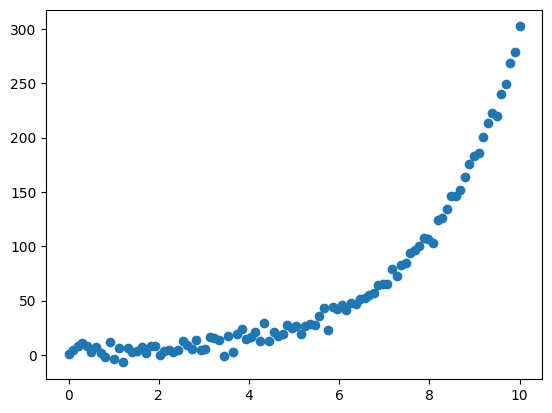

In [ ]:
# Generate synthetic exponential data
X = np.linspace(0, 10, 100)
true_a, true_b, true_c = 2, 0.5, 3  # Example parameters for the exponential function
Y = true_a * np.exp(true_b * X) + true_c + np.random.normal(-2, 5, len(X))  # Add some noise

data = []
for i in range(len(X)):
  data.append((X[i], Y[i]))

plt.scatter([d[0] for d in data],[d[1] for d in data])

In [ ]:
# learningRate = 0.025
learningRate = 0.00001

scalar = 2
growth = 0.5
vertical = 0

In [ ]:
def MeanSquareError():
  TotalSquareError = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    TotalSquareError += (scalar * exp(growth * x)) + vertical
  return TotalSquareError / len(data)

In [ ]:
def UpdateScalar():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = (y - ( (scalar * exp(growth * x)) + vertical))
    Total += error * exp(growth * x)
  return -2 * Total / len(data)

def UpdateGrowth():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = (y - ( (scalar * exp(growth * x)) + vertical))
    Total += error * scalar * x * exp(growth * x)
  return -2 * Total / len(data)

def UpdateVertical():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = (y - ( (scalar * exp(growth * x)) + vertical))
    Total += error
  return -2 * Total / len(data)

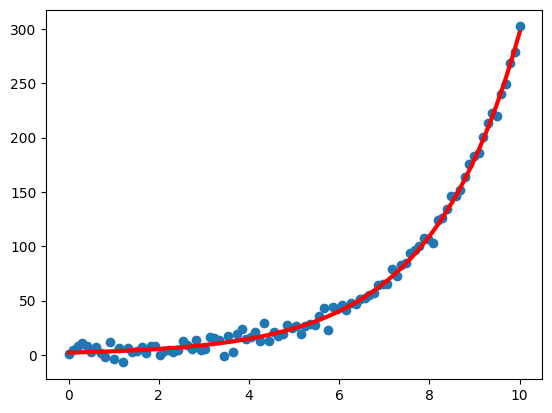

In [ ]:
def Line(x):
  return (scalar * exp(growth * x)) + vertical

plt.plot([d[0] for d in data],[Line(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

In [ ]:
MeanSquareError()

59.88215058323501

In [ ]:
for i in range(100):
  _g = UpdateGrowth()
  _s = UpdateScalar()
  vertical -= learningRate * UpdateVertical()
  growth -= learningRate * _g
  scalar -= learningRate * _s

MeanSquareError()

-0.40588775845520897

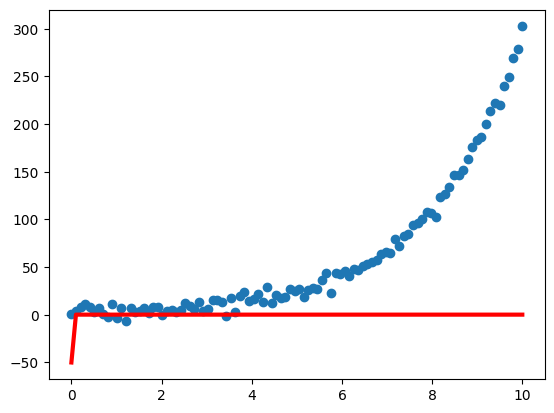

In [ ]:
plt.plot([d[0] for d in data],[Line(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])